In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from bbhx.waveformbuild import BBHWaveformFD
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from bbhx.response.fastfdresponse import LISATDIResponse
from bbhx.likelihood import Likelihood, HeterodynedLikelihood
from bbhx.utils.constants import *
from bbhx.utils.transform import *

from lisatools.sensitivity import get_sensitivity

np.random.seed(111222)

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.
No CuPy


In [5]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))

In [9]:
wave_gen

In [3]:
# set parameters
f_ref = 0.0  # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1 = 1e6 
m2 = 5e5
a1 = 0.2
a2 = 0.4
dist = 18e3  * PC_SI * 1e6 # 3e3 in Mpc 
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle 
t_ref = 0.5 * YRSID_SI  # t_ref  (in the SSB reference frame)

# frequencies to interpolate to
freq_new = np.logspace(-4, 0, 10000)
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

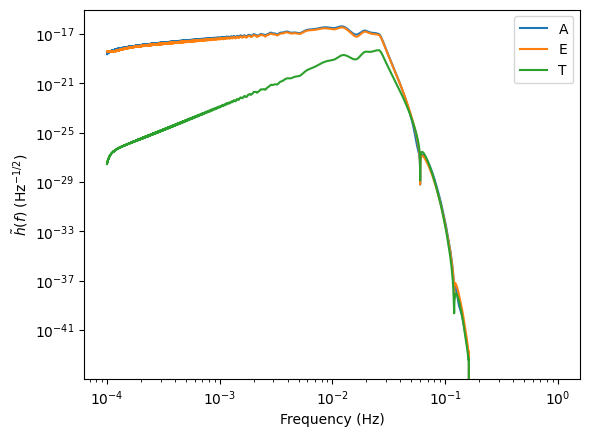

In [4]:
wave = wave_gen(m1, m2, a1, a2,
                          dist, phi_ref, f_ref, inc, lam, 
                          beta, psi, t_ref, freqs=freq_new,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0] 

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")


In [10]:
from lisagwresponse import GalacticBinary

In [14]:
t = np.arange(0, 1E4, 5) # sampled at 0.2 Hz
galbin = GalacticBinary(A=1E-20, f=1E-3, orbits="dist/orbit_data/orbits.h5", gw_beta=np.pi / 4, gw_lambda=0)

# response_12_21 = galbin.compute_gw_response(t, [12, 21])[0]
# response_all = galbin.compute_gw_response(t) # by default, all links

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported


In [15]:
galbin